In [25]:
%run "Ch00 - Basic Imports and Set ups.ipynb"

In Module 2 video 4, you learned how to find the normal distribution of multiple variables. Let us answer the question: Given that for one store we needed 1212 units of inventory, how much inventory does the retailer need in the warehouse to guarantee a fill rate of 95% in each of two stores with similar sales patterns?

Let's first import all required libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import math

Let's define the variables that will be used.  

In [2]:
#Expected Total Demand 
expTotDemand = 800

#Number of Stores
numStores = 2

#Independant Standard deviation
iStd = 250

#Number of iterations
n=1000

Next, calculate the standard deviation and the mean then plot the probability density function.

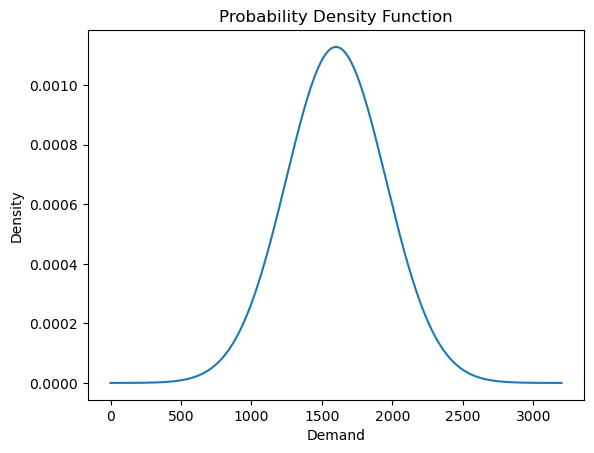

In [3]:
#Guaranteed supply if all stores get 1000 units
guaranteedSupply = 1000 * numStores

# Calculate the mean
mean = expTotDemand * numStores

#Calculate standard deviation 
std = math.sqrt(numStores) * iStd

#configure the line space
x = np.linspace(0, 1600 * numStores, n)

pdf_result = stats.norm.pdf(x,loc=mean,scale=std)

#Lable and plot the PDF against the pre-defined line space
plt.plot(x,pdf_result)
plt.xlabel('Demand')
plt.ylabel('Density')
plt.title("Probability Density Function")
plt.show()

Find the fill rate if 1000 units are in stock at each location. 

In [4]:
cdf = stats.norm.cdf(guaranteedSupply,mean,std)
cdf

np.float64(0.8710504823538303)

Next, calculate the Percentile point function (CDF inverse) to find how many units will be needed to fill 95% of orders.

In [5]:
ppf = stats.norm.ppf(0.95,mean,std)
ppf

np.float64(2181.543576838337)

Plot the PPF against the normal distribution curve. 

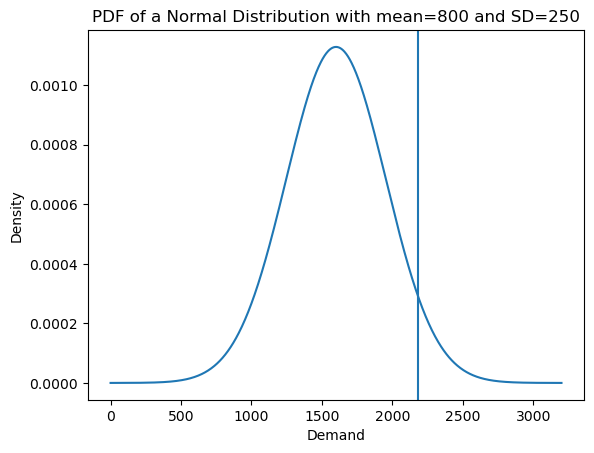

In [6]:
#Plot the PPF as a line 
plt.axvline(ppf)
plt.plot(x,pdf_result)

plt.xlabel('Demand')
plt.ylabel('Density')
plt.title("PDF of a Normal Distribution with mean=800 and SD=250")
plt.show()

Now let's see how we can perform our claculations on 5 independant stores. Change the corresponding variable 

In [ ]:
#Number of Stores
numStores = 12

Now re-calculate the dependant variables.

In [ ]:
#Guaranteed supply if all stores get 1000 units
guaranteedSupply = 1000 * numStores

#Calculate the mean
mean = expTotDemand * numStores

#Calculate standard deviation 
std = math.sqrt(numStores) * iStd


Display the new Probability density function. 

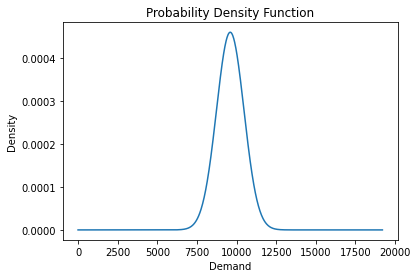

In [ ]:
#configure the line space
x = np.linspace(0, 1600 * numStores, n)

pdf_result = stats.norm.pdf(x,loc=mean,scale=std)

#Lable and plot the PDF against the pre-defined line space
plt.plot(x,pdf_result)
plt.xlabel('Demand')
plt.ylabel('Density')
plt.title("Probability Density Function")
plt.show()

Now what is the fill rate for all the sores comnined if each store gets 1000 units(guaranteed supply)? 

In [ ]:
cdf = stats.norm.cdf(guaranteedSupply,mean,std)
cdf

0.9972081915968106

How much inventory is needed for 95% fill rate at all the stores? 

In [ ]:
ppf = stats.norm.ppf(0.95,mean,std)
ppf

11024.485026446948

Let's plot the normal distribution along with 95% fill rate 

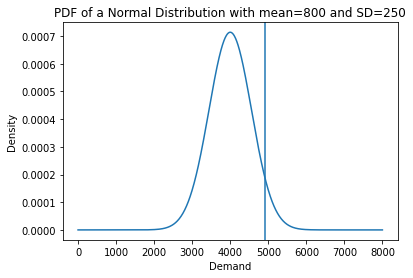

In [ ]:
#Plot the PPF as a line 
plt.axvline(ppf)
plt.plot(x,pdf_result)

plt.xlabel('Demand')
plt.ylabel('Density')
plt.title("PDF of a Normal Distribution with mean=800 and SD=250")
plt.show()

In [8]:
stats.norm.ppf(0.95,12*800,math.sqrt(12)*250)

np.float64(11024.485026446948)

In [9]:
(14532-11025)/14532

0.24132947976878613

In [13]:
cdf = stats.norm.cdf(9500,12*800,math.sqrt(12)*250)

In [14]:
cdf

np.float64(0.4540362776279876)

In [12]:
mean

1600

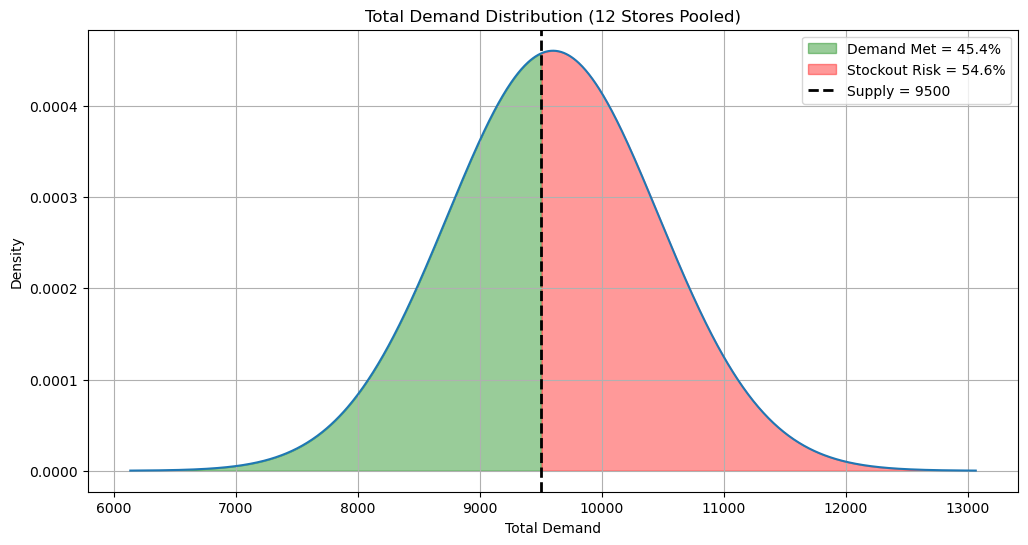

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------- GIVEN DATA ----------
stores = 12
mean_store = 800
std_store = 250
supply = 9500

# ---------- AGGREGATED DISTRIBUTION ----------
mean_total = stores * mean_store
std_total = np.sqrt(stores) * std_store

# ---------- X RANGE ----------
x = np.linspace(mean_total - 4*std_total,
                mean_total + 4*std_total,
                1000)

pdf = stats.norm.pdf(x, mean_total, std_total)

# ---------- SERVICE LEVEL ----------
service_level = stats.norm.cdf(supply, mean_total, std_total)
stockout = 1 - service_level

# ---------- PLOT ----------
plt.figure(figsize=(12,6))

plt.plot(x, pdf)

# Green Area → Demand Met
x_green = x[x <= supply]
plt.fill_between(x_green,
                 stats.norm.pdf(x_green, mean_total, std_total),
                 color='green',
                 alpha=0.4,
                 label=f'Demand Met = {service_level*100:.1f}%')

# Red Area → Demand Not Met
x_red = x[x > supply]
plt.fill_between(x_red,
                 stats.norm.pdf(x_red, mean_total, std_total),
                 color='red',
                 alpha=0.4,
                 label=f'Stockout Risk = {stockout*100:.1f}%')

# Supply Line
plt.axvline(supply,
            color='black',
            linestyle='--',
            linewidth=2,
            label=f'Supply = {supply}')

plt.title('Total Demand Distribution (12 Stores Pooled)')
plt.xlabel('Total Demand')
plt.ylabel('Density')

plt.legend()
plt.grid(True)

plt.show()

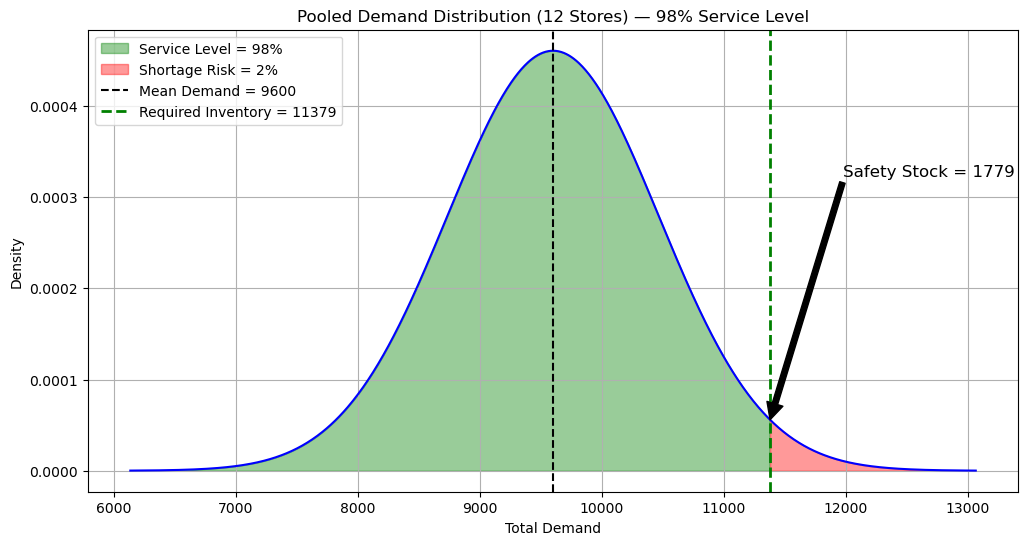

Required Inventory = 11378.60
Safety Stock = 1778.60


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------- GIVEN ----------
stores = 12
mean_store = 800
std_store = 250
service_level = 0.98

# ---------- AGGREGATE DEMAND ----------
mean_total = stores * mean_store
std_total = np.sqrt(stores) * std_store

# ---------- REQUIRED INVENTORY ----------
required_inventory = stats.norm.ppf(service_level,
                                    loc=mean_total,
                                    scale=std_total)

# ---------- SAFETY STOCK ----------
safety_stock = required_inventory - mean_total

# ---------- X RANGE ----------
x = np.linspace(mean_total - 4*std_total,
                mean_total + 4*std_total,
                1000)

pdf = stats.norm.pdf(x, mean_total, std_total)

# ---------- PLOT ----------
plt.figure(figsize=(12,6))

plt.plot(x, pdf, color='blue')

# Green shaded service region
x_green = x[x <= required_inventory]

plt.fill_between(x_green,
                 stats.norm.pdf(x_green, mean_total, std_total),
                 color='green',
                 alpha=0.4,
                 label=f'Service Level = {service_level*100:.0f}%')

# Remaining risk region
x_red = x[x > required_inventory]

plt.fill_between(x_red,
                 stats.norm.pdf(x_red, mean_total, std_total),
                 color='red',
                 alpha=0.4,
                 label=f'Shortage Risk = {(1-service_level)*100:.0f}%')

# Mean line
plt.axvline(mean_total,
            linestyle='--',
            color='black',
            label=f'Mean Demand = {mean_total:.0f}')

# Inventory line
plt.axvline(required_inventory,
            linestyle='--',
            color='green',
            linewidth=2,
            label=f'Required Inventory = {required_inventory:.0f}')

# Safety stock callout
plt.annotate(f"Safety Stock = {safety_stock:.0f}",
             xy=(required_inventory,
                 stats.norm.pdf(required_inventory,
                                mean_total,
                                std_total)),
             xytext=(required_inventory + 600,
                     max(pdf)*0.7),
             arrowprops=dict(facecolor='black'),
             fontsize=12)

plt.title("Pooled Demand Distribution (12 Stores) — 98% Service Level")
plt.xlabel("Total Demand")
plt.ylabel("Density")

plt.legend()
plt.grid(True)

plt.show()

print(f"Required Inventory = {required_inventory:.2f}")
print(f"Safety Stock = {safety_stock:.2f}")

In [20]:
11379-1779

9600